<a href="https://colab.research.google.com/github/thigas77-bit/K-Means_Clusters/blob/main/CLUSTERIZA%C3%87%C3%83O.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementação e Análise do K-Means

Implementação do algoritmo K-Means do zero para agrupamento de dados bidimensionais.

## 1. Importações

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans as SklearnKMeans
import time
import warnings
warnings.filterwarnings('ignore')

## 2. Geração dos Datasets (4 Cenários)

In [2]:
# -------------------------------------------------------
# Cenário 1: Clusters Isolados
# Clusters bem separados, baixa dispersão, fácil de separar
# -------------------------------------------------------
X1, y1 = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=1.0,       # baixa dispersão -> clusters isolados
    center_box=(-20.0, 20.0),
    shuffle=True,
    random_state=3
)

# -------------------------------------------------------
# Cenário 2: Clusters Próximos com Sobreposição
# Centros próximos e alta dispersão -> difícil separar
# -------------------------------------------------------
X2, y2 = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=2.8,       # alta dispersão -> mais sobreposição
    center_box=(-5.0, 5.0), # centros mais próximos
    shuffle=True,
    random_state=2
)

# -------------------------------------------------------
# Cenário 3: Clusters Alongados e Semelhantes
# Aplicamos uma transformação linear para 'esticar' os clusters
# O K-Means assume clusters esféricos, então vai ter dificuldade aqui
# -------------------------------------------------------
X3, y3 = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=1.5,
    random_state=34
)
# Matriz de transformação: cria alongamento e inclinação nos clusters
transformacao = np.array([
    [0.6, -0.6],
    [-0.4, 1.2]
])
X3 = np.dot(X3, transformacao)  # aplica transformação

# -------------------------------------------------------
# Cenário 4: Sem Clusters Definidos
# Distribuição uniforme aleatória - não há estrutura de grupos
# -------------------------------------------------------
np.random.seed(42)
X4 = np.random.uniform(low=-10, high=10, size=(1200, 2))
y4 = np.zeros(1200, dtype=int)  # sem rótulos reais

print("Cenário 1 - shape:", X1.shape)
print("Cenário 2 - shape:", X2.shape)
print("Cenário 3 - shape:", X3.shape)
print("Cenário 4 - shape:", X4.shape)

Cenário 1 - shape: (1200, 2)
Cenário 2 - shape: (1200, 2)
Cenário 3 - shape: (1200, 2)
Cenário 4 - shape: (1200, 2)


### Gráfico 1: Dataset Original (sem agrupamento K-Means)

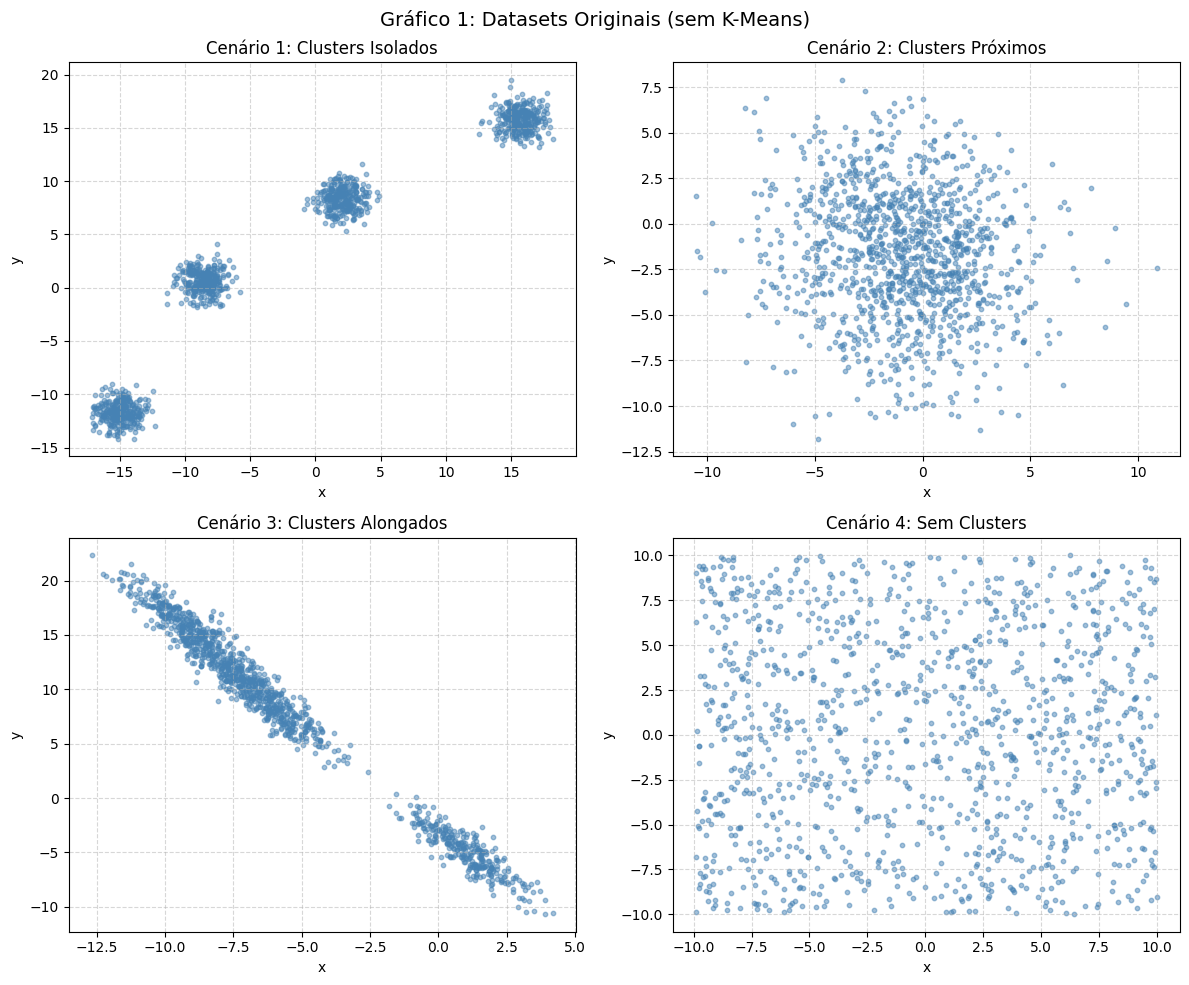

In [3]:
# Exibe os 4 cenários sem nenhum agrupamento do K-Means
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = [(X1, y1, 'Cenário 1: Clusters Isolados'),
            (X2, y2, 'Cenário 2: Clusters Próximos'),
            (X3, y3, 'Cenário 3: Clusters Alongados'),
            (X4, y4, 'Cenário 4: Sem Clusters')]

for ax, (X, y, titulo) in zip(axes.flatten(), datasets):
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.5, color='steelblue')
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Gráfico 1: Datasets Originais (sem K-Means)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Normalização dos Dados

MinMaxScaler para normalizar os dados no intervalo [0, 1].

A normalização é importante porque o K-Means usa distância euclidiana. Se as variáveis tiverem escalas muito diferentes, a variável com maior escala dominaria o cálculo da distância, distorcendo os clusters.

In [4]:
# MinMaxScaler transforma cada variável para o intervalo [0, 1]
# Fórmula: x_norm = (x - x_min) / (x_max - x_min)

scaler = MinMaxScaler()

X1_norm = scaler.fit_transform(X1)
X2_norm = scaler.fit_transform(X2)
X3_norm = scaler.fit_transform(X3)
X4_norm = scaler.fit_transform(X4)

print("Dados normalizados para o intervalo [0, 1]")
print("X1_norm min/max:", X1_norm.min().round(2), X1_norm.max().round(2))
print("X2_norm min/max:", X2_norm.min().round(2), X2_norm.max().round(2))

Dados normalizados para o intervalo [0, 1]
X1_norm min/max: 0.0 1.0
X2_norm min/max: 0.0 1.0


## 4. Implementação do K-Means do Zero

In [5]:
def dist_calc1(ponto, centroide):
    """
    Calcula a distância euclidiana entre um ponto e um centróide.
    Fórmula: d = sqrt((x1 - y1)^2 + (x2 - y2)^2)
    Referência: https://en.wikipedia.org/wiki/Euclidean_distance
    """
    return np.sqrt(np.sum((ponto - centroide) ** 2))


def inicializar_centroides(X, k, random_state=None):
    """
    Inicializa os centróides escolhendo k pontos aleatórios do dataset.
    Estratégia simples: sorteia k índices sem repetição e retorna esses pontos.
    """
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=k, replace=False)
    return X[indices].copy()


def atribuir_clusters(X, centroides):
    """
    Para cada ponto em X, calcula a distância até cada centróide
    e atribui o ponto ao cluster do centróide mais próximo.
    Retorna um array com o índice do cluster de cada ponto.
    """
    rotulos = np.zeros(len(X), dtype=int)
    for i, ponto in enumerate(X):
        distancias = [dist_calc1(ponto, c) for c in centroides]
        rotulos[i] = np.argmin(distancias)  # cluster com menor distância
    return rotulos


def atualizar_centroides(X, rotulos, k, centroides_atuais):
    """
    Recalcula a posição de cada centróide como a média dos pontos do cluster.
    Tratamento de cluster vazio: se um cluster ficar sem pontos,
    reinicializa o centróide no ponto mais distante do centróide mais populoso.
    Estratégia documentada: 'Max-distance restart' - evita centróides mortos.
    """
    novos_centroides = np.zeros((k, X.shape[1]))
    cluster_vazio_ocorreu = False

    for j in range(k):
        pontos_cluster = X[rotulos == j]  # pontos atribuídos ao cluster j

        if len(pontos_cluster) == 0:
            # Cluster vazio! Estratégia: mover o centróide para o ponto
            # mais distante de qualquer centróide atual
            cluster_vazio_ocorreu = True
            distancias_max = np.array([
                min(dist_calc1(p, c) for c in centroides_atuais)
                for p in X
            ])
            novos_centroides[j] = X[np.argmax(distancias_max)]
        else:
            novos_centroides[j] = pontos_cluster.mean(axis=0)

    return novos_centroides, cluster_vazio_ocorreu


def calcular_variabilidade(X, rotulos, centroides):
    """
    Calcula a variabilidade intra-cluster de cada cluster:
    soma das distâncias quadráticas dos pontos ao seu centróide.
    Retorna a variabilidade de cada cluster e a soma total.
    """
    k = len(centroides)
    variabilidades = np.zeros(k)
    for j in range(k):
        pontos = X[rotulos == j]
        if len(pontos) > 0:
            variabilidades[j] = np.sum((pontos - centroides[j]) ** 2)
    return variabilidades, variabilidades.sum()


def calcular_dissimilaridade(centroides):
    """
    Calcula a dissimilaridade entre clusters:
    média das distâncias euclidianas entre todos os pares de centróides.
    Quanto maior, mais separados estão os clusters entre si.
    """
    k = len(centroides)
    distancias = []
    for i in range(k):
        for j in range(i + 1, k):
            distancias.append(dist_calc1(centroides[i], centroides[j]))
    return np.mean(distancias) if distancias else 0.0


def kmeans(X, k, max_iter=300, tol=1e-4, random_state=None):
    """
    Implementação principal do algoritmo K-Means.

    Parâmetros:
        X           : array de dados (n_amostras, n_features)
        k           : número de clusters
        max_iter    : número máximo de iterações
        tol         : tolerância para critério de parada por movimento
        random_state: semente para reprodutibilidade

    Retorna um dicionário com:
        - centroides: posição final dos centróides
        - rotulos: cluster de cada ponto
        - historico: lista com o estado de cada iteração
        - n_iter: quantidade de iterações executadas
        - criterio_parada: qual critério encerrou o algoritmo
        - variabilidades_finais: variabilidade de cada cluster
        - variabilidade_total: soma total das variabilidades
        - dissimilaridade_final: dissimilaridade entre centróides
        - cluster_vazio: se houve cluster vazio em alguma iteração
        - centroides_iniciais: posição inicial dos centróides
    """
    # Passo 1: Inicializar centróides
    centroides = inicializar_centroides(X, k, random_state)
    centroides_iniciais = centroides.copy()

    historico = []       # guarda o estado de cada iteração
    cluster_vazio = False
    criterio_parada = 'max_iter'  # valor padrão

    for iteracao in range(max_iter):
        # Passo 2 e 3: Calcular distâncias e atribuir clusters
        rotulos = atribuir_clusters(X, centroides)

        # Passo 4: Atualizar centróides
        novos_centroides, houve_vazio = atualizar_centroides(X, rotulos, k, centroides)
        if houve_vazio:
            cluster_vazio = True

        # Calcular métricas da iteração
        deslocamento = np.sum([dist_calc1(novos_centroides[j], centroides[j]) for j in range(k)])
        variabs, var_total = calcular_variabilidade(X, rotulos, novos_centroides)
        dissim = calcular_dissimilaridade(novos_centroides)

        # Salvar histórico da iteração
        historico.append({
            'iteracao': iteracao + 1,
            'centroides': novos_centroides.copy(),
            'rotulos': rotulos.copy(),
            'variabilidades_clusters': variabs.copy(),
            'variabilidade_total': var_total,
            'dissimilaridade': dissim,
            'deslocamento': deslocamento
        })

        # Passo 5: Critérios de parada
        # Critério 1: centróides não mudaram (deslocamento zero)
        if deslocamento == 0:
            criterio_parada = 'centroides_sem_mudanca'
            centroides = novos_centroides
            break

        # Critério 2: movimento menor que tolerância
        if deslocamento < tol:
            criterio_parada = 'tolerancia_atingida'
            centroides = novos_centroides
            break

        centroides = novos_centroides

    # Critério 3: número máximo de iterações (já definido como padrão)

    # Calcula métricas finais
    rotulos_finais = atribuir_clusters(X, centroides)
    var_finais, var_total_final = calcular_variabilidade(X, rotulos_finais, centroides)
    dissim_final = calcular_dissimilaridade(centroides)

    return {
        'centroides': centroides,
        'rotulos': rotulos_finais,
        'historico': historico,
        'n_iter': len(historico),
        'criterio_parada': criterio_parada,
        'variabilidades_finais': var_finais,
        'variabilidade_total': var_total_final,
        'dissimilaridade_final': dissim_final,
        'cluster_vazio': cluster_vazio,
        'centroides_iniciais': centroides_iniciais
    }

## 5. Executando o K-Means nos 4 Cenários

In [6]:
# Executamos com k=4 (número real de clusters gerados)
# Usamos dados normalizados para melhor performance

K = 4
SEED = 42

res1 = kmeans(X1_norm, k=K, max_iter=300, tol=1e-4, random_state=SEED)
res2 = kmeans(X2_norm, k=K, max_iter=300, tol=1e-4, random_state=SEED)
res3 = kmeans(X3_norm, k=K, max_iter=300, tol=1e-4, random_state=SEED)
res4 = kmeans(X4_norm, k=K, max_iter=300, tol=1e-4, random_state=SEED)

for i, res in enumerate([res1, res2, res3, res4], 1):
    print(f"--- Cenário {i} ---")
    print(f"  Iterações: {res['n_iter']}")
    print(f"  Critério de parada: {res['criterio_parada']}")
    print(f"  Variabilidade total: {res['variabilidade_total']:.4f}")
    print(f"  Dissimilaridade final: {res['dissimilaridade_final']:.4f}")
    print(f"  Cluster vazio ocorreu: {res['cluster_vazio']}")
    print()

--- Cenário 1 ---
  Iterações: 3
  Critério de parada: centroides_sem_mudanca
  Variabilidade total: 2.0231
  Dissimilaridade final: 0.6680
  Cluster vazio ocorreu: False

--- Cenário 2 ---
  Iterações: 32
  Critério de parada: centroides_sem_mudanca
  Variabilidade total: 21.2079
  Dissimilaridade final: 0.3019
  Cluster vazio ocorreu: False

--- Cenário 3 ---
  Iterações: 7
  Critério de parada: centroides_sem_mudanca
  Variabilidade total: 8.1840
  Dissimilaridade final: 0.5568
  Cluster vazio ocorreu: False

--- Cenário 4 ---
  Iterações: 10
  Critério de parada: centroides_sem_mudanca
  Variabilidade total: 50.2211
  Dissimilaridade final: 0.5783
  Cluster vazio ocorreu: False



## 6. Gráfico 2: Clusters Finais com Centróides e Variabilidade

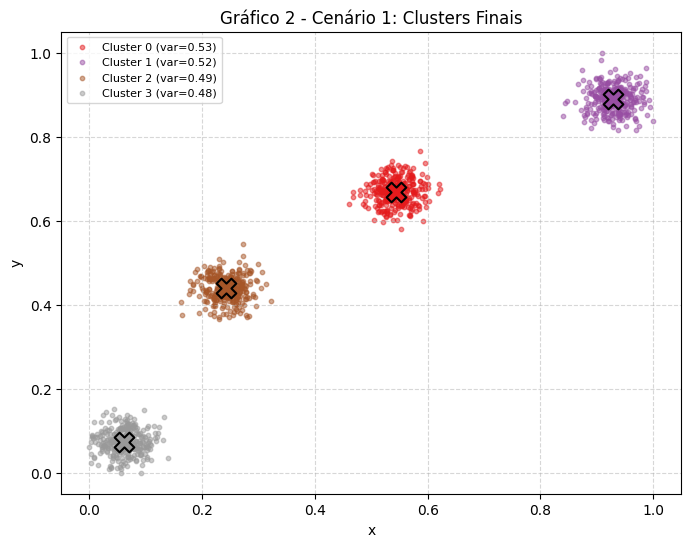

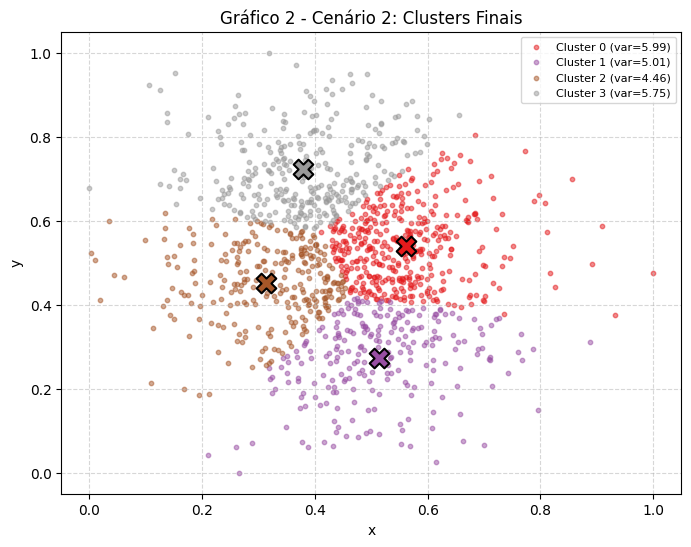

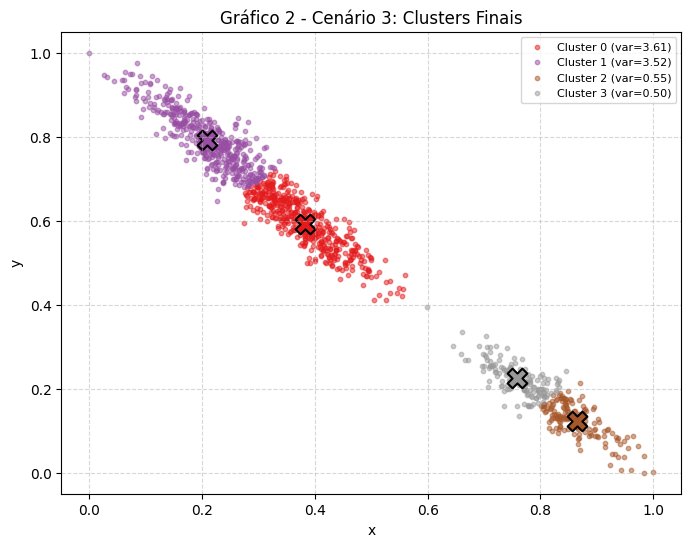

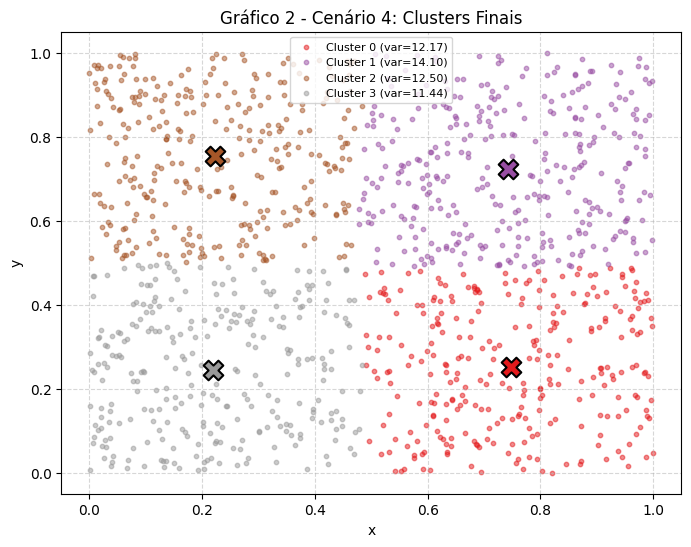

In [7]:
def plotar_clusters_finais(X, resultado, titulo):
    """
    Plota os pontos coloridos por cluster, os centróides destacados
    e mostra a variabilidade de cada cluster na legenda.
    """
    rotulos = resultado['rotulos']
    centroides = resultado['centroides']
    variabs = resultado['variabilidades_finais']
    k = len(centroides)
    cores = plt.cm.Set1(np.linspace(0, 1, k))

    plt.figure(figsize=(8, 6))
    for j in range(k):
        pts = X[rotulos == j]
        plt.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.5, color=cores[j],
                    label=f'Cluster {j} (var={variabs[j]:.2f})')
        plt.scatter(centroides[j, 0], centroides[j, 1], s=200,
                    marker='X', color=cores[j], edgecolors='black', linewidths=1.5)
    plt.title(titulo)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


plotar_clusters_finais(X1_norm, res1, 'Gráfico 2 - Cenário 1: Clusters Finais')
plotar_clusters_finais(X2_norm, res2, 'Gráfico 2 - Cenário 2: Clusters Finais')
plotar_clusters_finais(X3_norm, res3, 'Gráfico 2 - Cenário 3: Clusters Finais')
plotar_clusters_finais(X4_norm, res4, 'Gráfico 2 - Cenário 4: Clusters Finais')

## 7. Gráficos 3, 4 e 5: Variabilidade, Dissimilaridade e Deslocamento por Iteração

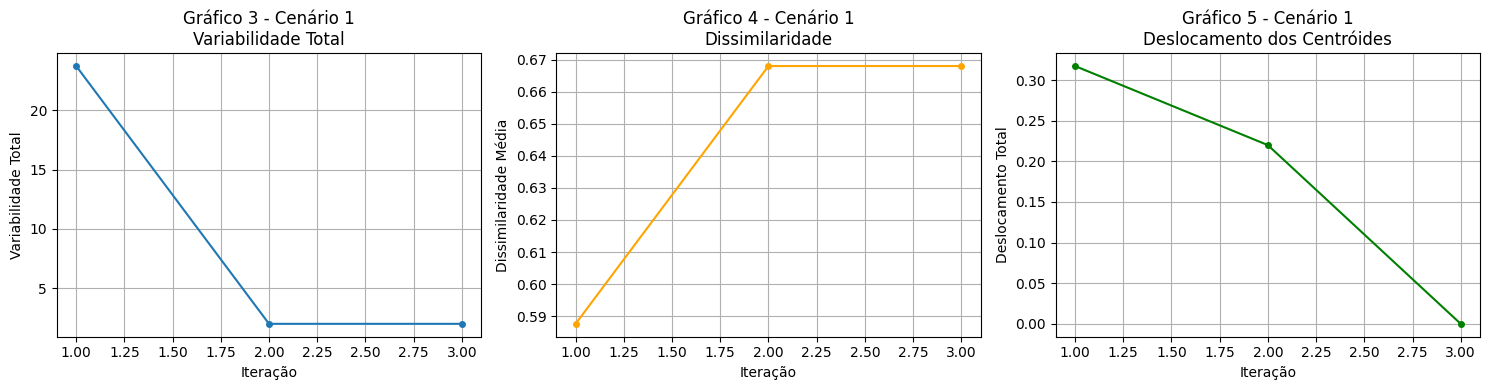

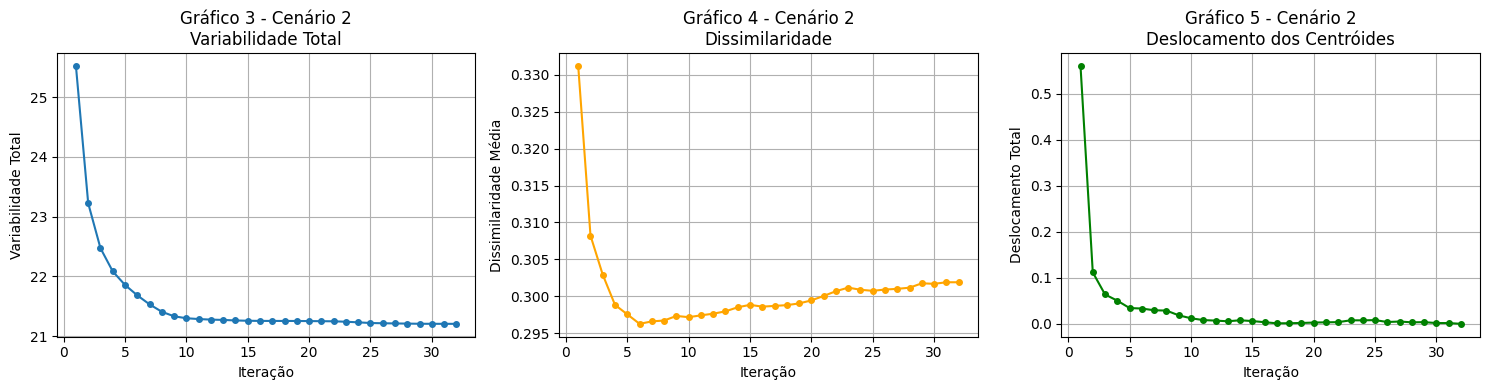

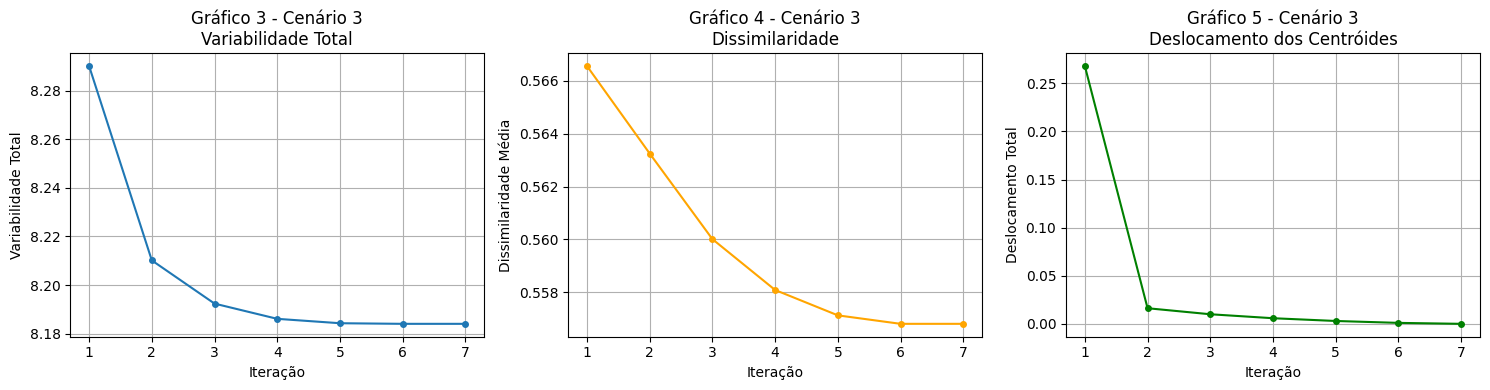

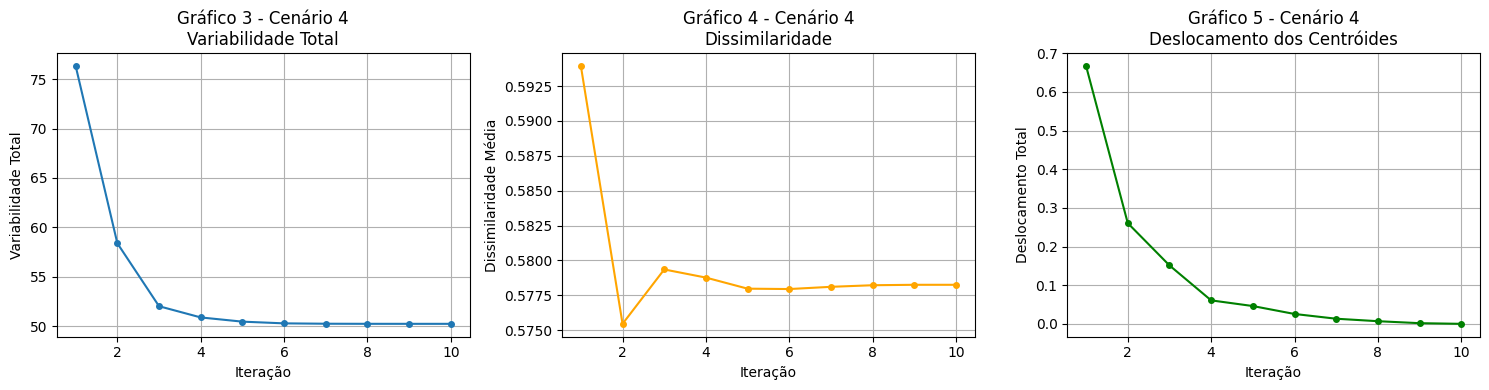

In [8]:
def plotar_metricas_iteracoes(resultado, titulo_base):
    """
    Plota 3 gráficos a partir do histórico de iterações:
    - Variabilidade total (o quanto os pontos variam dentro dos clusters)
    - Dissimilaridade (o quanto os centróides estão distantes entre si)
    - Deslocamento dos centróides (o quanto eles se moveram)
    """
    hist = resultado['historico']
    iters = [h['iteracao'] for h in hist]
    var_total = [h['variabilidade_total'] for h in hist]
    dissim = [h['dissimilaridade'] for h in hist]
    deslocamentos = [h['deslocamento'] for h in hist]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gráfico 3: Variabilidade total
    axes[0].plot(iters, var_total, marker='o', markersize=4)
    axes[0].set_title(f'Gráfico 3 - {titulo_base}\nVariabilidade Total')
    axes[0].set_xlabel('Iteração')
    axes[0].set_ylabel('Variabilidade Total')
    axes[0].grid(True)

    # Gráfico 4: Dissimilaridade
    axes[1].plot(iters, dissim, marker='o', markersize=4, color='orange')
    axes[1].set_title(f'Gráfico 4 - {titulo_base}\nDissimilaridade')
    axes[1].set_xlabel('Iteração')
    axes[1].set_ylabel('Dissimilaridade Média')
    axes[1].grid(True)

    # Gráfico 5: Deslocamento dos centróides
    axes[2].plot(iters, deslocamentos, marker='o', markersize=4, color='green')
    axes[2].set_title(f'Gráfico 5 - {titulo_base}\nDeslocamento dos Centróides')
    axes[2].set_xlabel('Iteração')
    axes[2].set_ylabel('Deslocamento Total')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


plotar_metricas_iteracoes(res1, 'Cenário 1')
plotar_metricas_iteracoes(res2, 'Cenário 2')
plotar_metricas_iteracoes(res3, 'Cenário 3')
plotar_metricas_iteracoes(res4, 'Cenário 4')

## 8. Gráfico 6: Evolução da Convergência (Iterações Intermediárias)

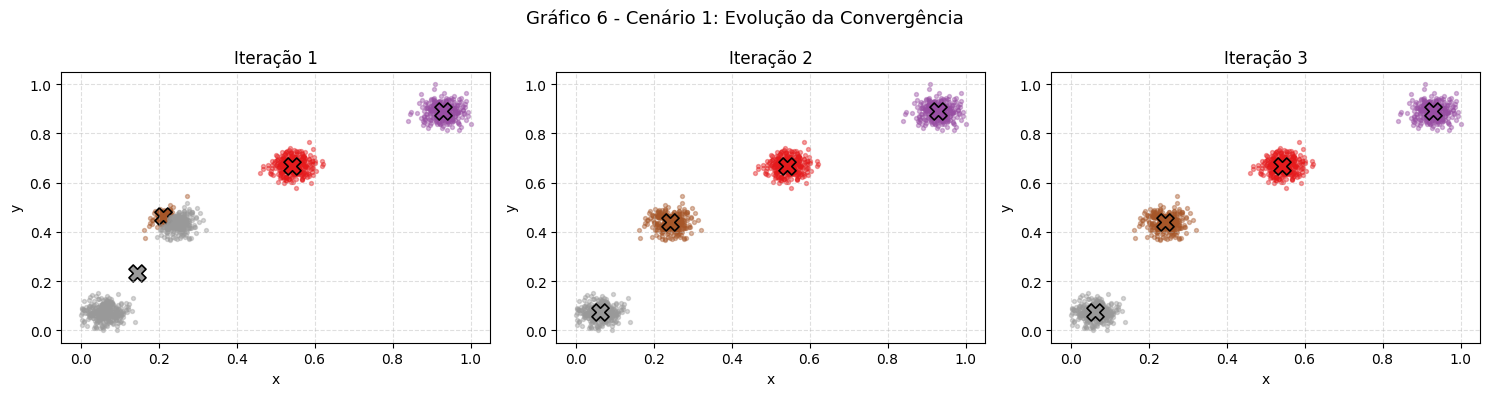

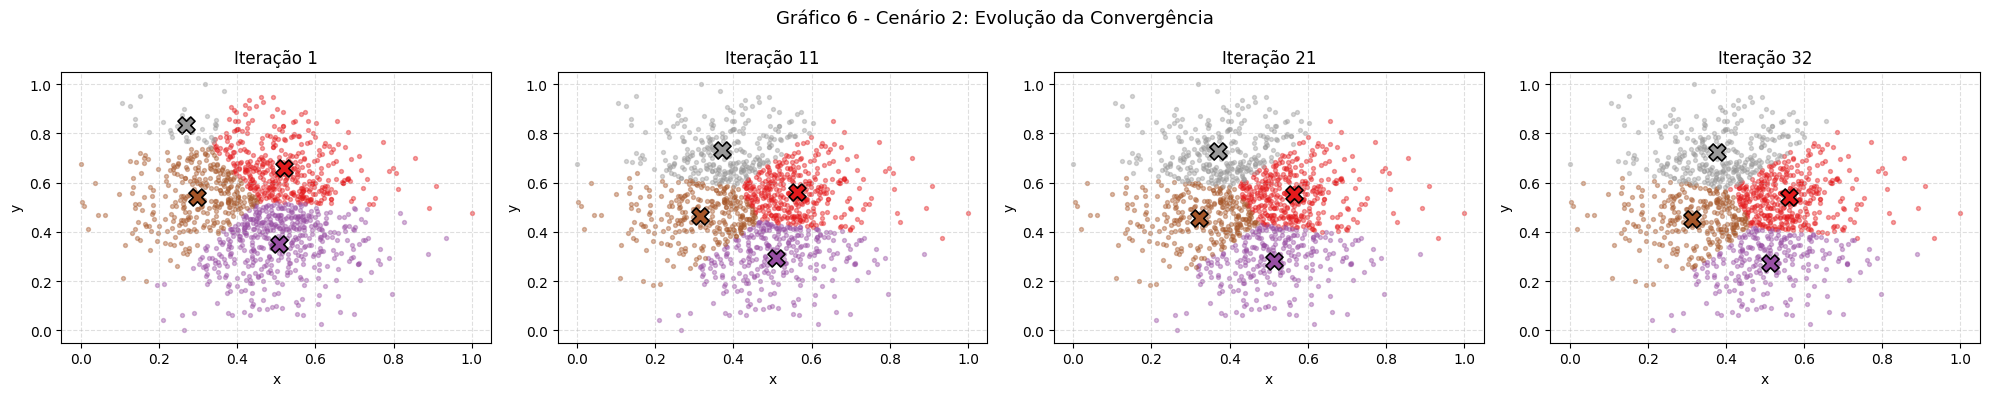

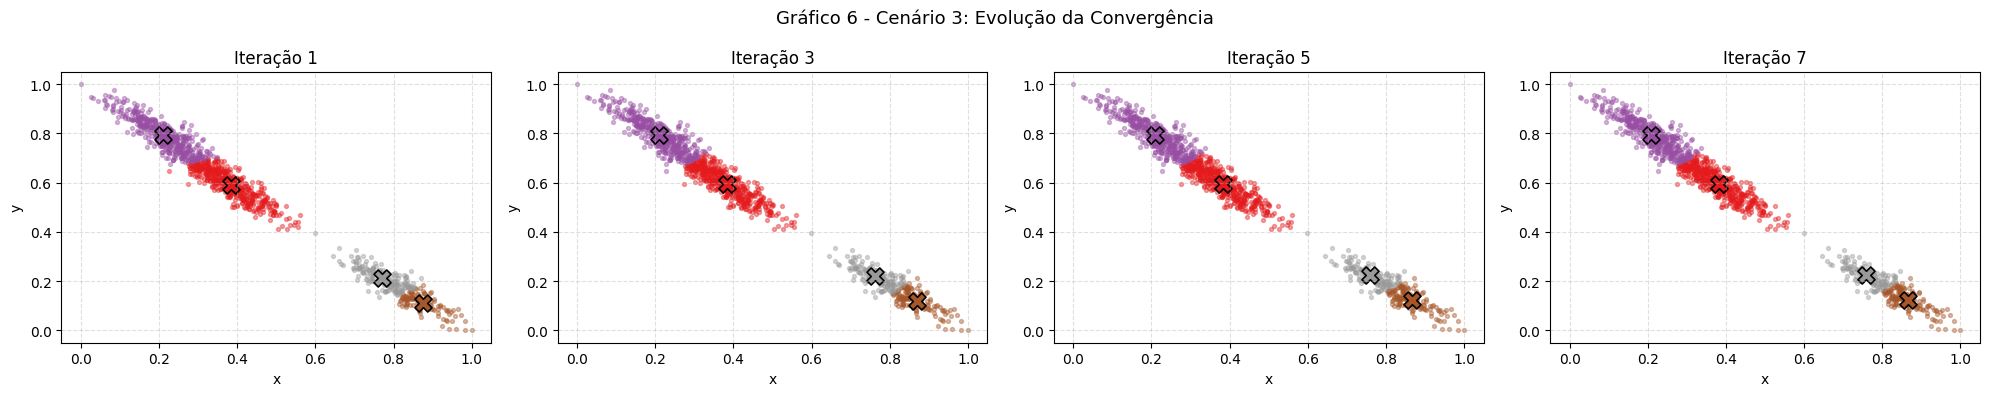

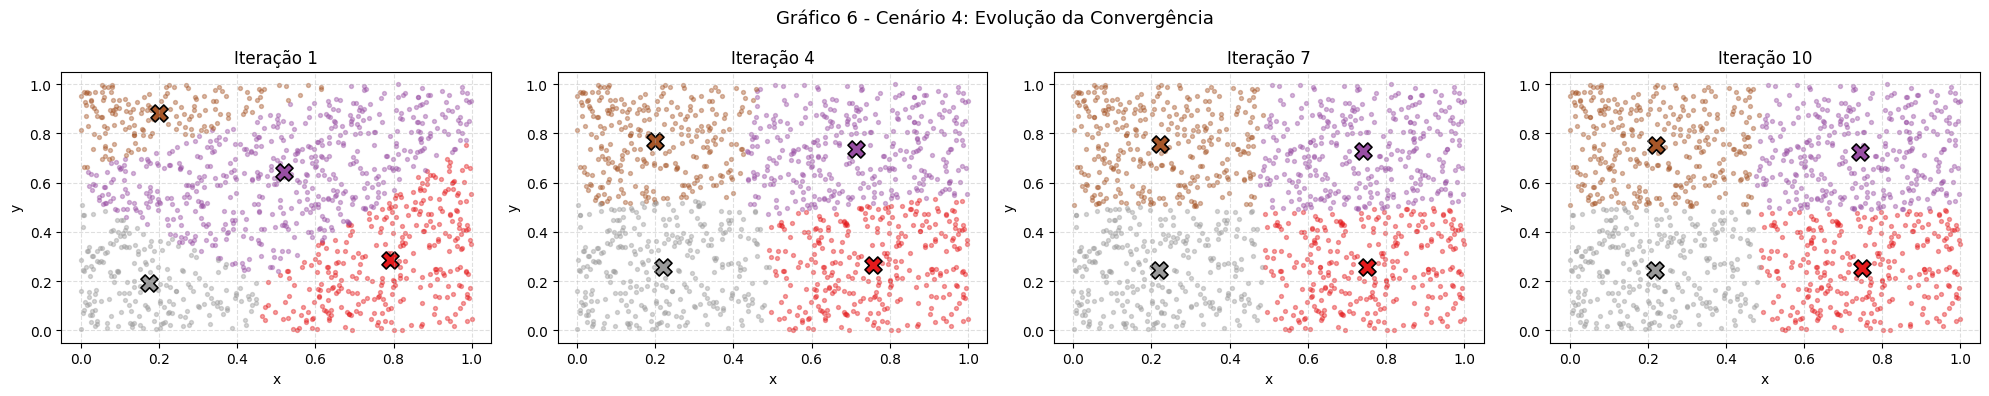

In [9]:
def plotar_convergencia(X, resultado, titulo_base, n_snapshots=4):
    """
    Mostra a evolução dos clusters e centróides ao longo das iterações.
    Seleciona n_snapshots iterações igualmente espaçadas para visualização.
    """
    hist = resultado['historico']
    n_iter = len(hist)

    # Seleciona índices igualmente espaçados + última iteração
    indices = np.linspace(0, n_iter - 1, n_snapshots, dtype=int)
    indices = sorted(set(indices.tolist() + [n_iter - 1]))

    k = len(hist[0]['centroides'])
    cores = plt.cm.Set1(np.linspace(0, 1, k))

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        estado = hist[idx]
        rotulos = estado['rotulos']
        centroides = estado['centroides']

        for j in range(k):
            pts = X[rotulos == j]
            ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.4, color=cores[j])
            ax.scatter(centroides[j, 0], centroides[j, 1], s=150,
                       marker='X', color=cores[j], edgecolors='black', linewidths=1.2)

        ax.set_title(f'Iteração {estado["iteracao"]}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f'Gráfico 6 - {titulo_base}: Evolução da Convergência', fontsize=13)
    plt.tight_layout()
    plt.show()


plotar_convergencia(X1_norm, res1, 'Cenário 1')
plotar_convergencia(X2_norm, res2, 'Cenário 2')
plotar_convergencia(X3_norm, res3, 'Cenário 3')
plotar_convergencia(X4_norm, res4, 'Cenário 4')

## 9. Análise de Inicialização

Executamos o K-Means várias vezes com sementes diferentes para ver como a inicialização afeta o resultado.

In [10]:
def analise_inicializacoes(X, k, n_runs=10, max_iter=300, tol=1e-4):
    """
    Executa o K-Means n_runs vezes com sementes diferentes.
    Registra os resultados de cada execução para comparação.
    Retorna a lista de resultados e o melhor (menor variabilidade total).
    """
    resultados = []
    for seed in range(n_runs):
        res = kmeans(X, k=k, max_iter=max_iter, tol=tol, random_state=seed)
        resultados.append({
            'seed': seed,
            'centroides_iniciais': res['centroides_iniciais'],
            'centroides_finais': res['centroides'],
            'n_iter': res['n_iter'],
            'variabilidade_total': res['variabilidade_total'],
            'dissimilaridade': res['dissimilaridade_final'],
            'cluster_vazio': res['cluster_vazio'],
            'criterio_parada': res['criterio_parada']
        })
    # Melhor resultado = menor variabilidade total
    melhor = min(resultados, key=lambda r: r['variabilidade_total'])
    return resultados, melhor


print("=== Análise de Inicializações - Cenário 1 ===")
runs1, melhor1 = analise_inicializacoes(X1_norm, k=4)
for r in runs1:
    print(f"  Seed={r['seed']} | Iter={r['n_iter']} | Var={r['variabilidade_total']:.4f} "
          f"| Dissim={r['dissimilaridade']:.4f} | VazioOcorreu={r['cluster_vazio']} | Parada={r['criterio_parada']}")
print(f"  -> Melhor seed: {melhor1['seed']} com variabilidade {melhor1['variabilidade_total']:.4f}")

print("\n=== Análise de Inicializações - Cenário 2 ===")
runs2, melhor2 = analise_inicializacoes(X2_norm, k=4)
for r in runs2:
    print(f"  Seed={r['seed']} | Iter={r['n_iter']} | Var={r['variabilidade_total']:.4f} "
          f"| Dissim={r['dissimilaridade']:.4f} | VazioOcorreu={r['cluster_vazio']} | Parada={r['criterio_parada']}")
print(f"  -> Melhor seed: {melhor2['seed']} com variabilidade {melhor2['variabilidade_total']:.4f}")

print("\n=== Análise de Inicializações - Cenário 3 ===")
runs3, melhor3 = analise_inicializacoes(X3_norm, k=4)
for r in runs3:
    print(f"  Seed={r['seed']} | Iter={r['n_iter']} | Var={r['variabilidade_total']:.4f} "
          f"| Dissim={r['dissimilaridade']:.4f} | VazioOcorreu={r['cluster_vazio']} | Parada={r['criterio_parada']}")
print(f"  -> Melhor seed: {melhor3['seed']} com variabilidade {melhor3['variabilidade_total']:.4f}")

=== Análise de Inicializações - Cenário 1 ===
  Seed=0 | Iter=7 | Var=23.3127 | Dissim=0.7126 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=1 | Iter=12 | Var=26.7536 | Dissim=0.5850 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=2 | Iter=3 | Var=2.0231 | Dissim=0.6680 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=3 | Iter=13 | Var=2.0231 | Dissim=0.6680 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=4 | Iter=3 | Var=2.0231 | Dissim=0.6680 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=5 | Iter=3 | Var=2.0231 | Dissim=0.6680 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=6 | Iter=3 | Var=2.0231 | Dissim=0.6680 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=7 | Iter=9 | Var=31.4670 | Dissim=0.5694 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=8 | Iter=13 | Var=26.7529 | Dissim=0.5851 | VazioOcorreu=False | Parada=centroides_sem_mudanca
  Seed=9 | Iter=19 | Var=2.0231 | Dissim=0.6680

## 10. Comparação: Dados Normalizados vs Não Normalizados

Comparação: Dados Originais vs Normalizados (k=4, seed=42)

Cenário      Tipo               Var Total  Iterações     Dissim
--------------------------------------------------------------
Cenário 1    Original             2395.26          3    23.0789
Cenário 1    Normalizado           2.0231          3     0.6680

Cenário 2    Original             9000.30         28     6.0714
Cenário 2    Normalizado          21.2079         32     0.3019

Cenário 3    Original             5727.63         10    14.6378
Cenário 3    Normalizado           8.1840          7     0.5568

Cenário 4    Original            19942.28         10    11.5215
Cenário 4    Normalizado          50.2211         10     0.5783



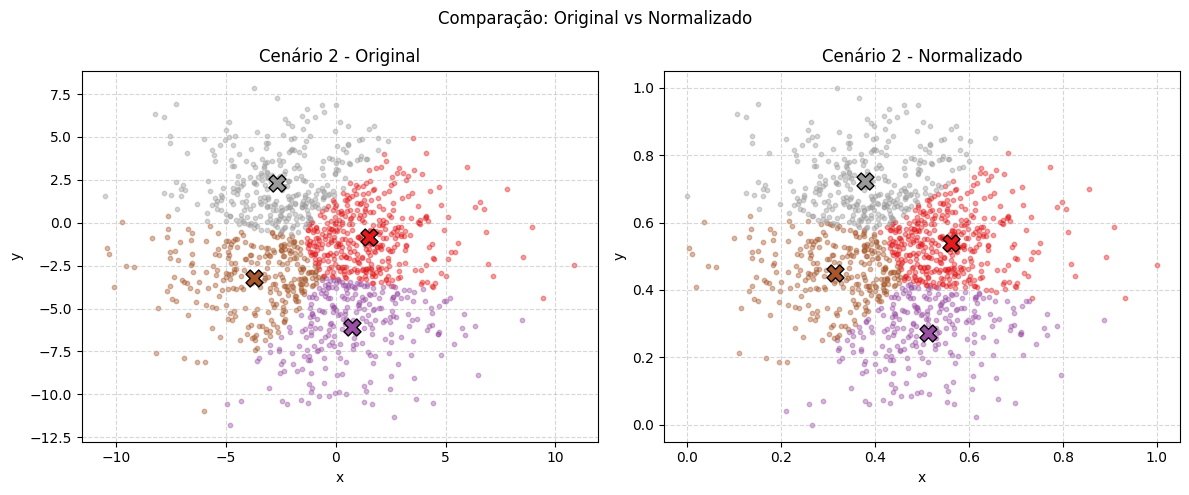

In [11]:
# Compara o resultado do K-Means com e sem normalização para cada cenário
# Usamos o cenário 2 como exemplo mais interessante (clusters próximos)

datasets_comp = [
    (X1, X1_norm, y1, 'Cenário 1'),
    (X2, X2_norm, y2, 'Cenário 2'),
    (X3, X3_norm, y3, 'Cenário 3'),
    (X4, X4_norm, y4, 'Cenário 4'),
]

print("Comparação: Dados Originais vs Normalizados (k=4, seed=42)\n")
print(f"{'Cenário':<12} {'Tipo':<15} {'Var Total':>12} {'Iterações':>10} {'Dissim':>10}")
print("-" * 62)

for X_orig, X_norm, y, nome in datasets_comp:
    r_orig = kmeans(X_orig, k=4, random_state=42)
    r_norm = kmeans(X_norm, k=4, random_state=42)
    print(f"{nome:<12} {'Original':<15} {r_orig['variabilidade_total']:>12.2f} "
          f"{r_orig['n_iter']:>10} {r_orig['dissimilaridade_final']:>10.4f}")
    print(f"{nome:<12} {'Normalizado':<15} {r_norm['variabilidade_total']:>12.4f} "
          f"{r_norm['n_iter']:>10} {r_norm['dissimilaridade_final']:>10.4f}")
    print()

# Plota lado a lado para o cenário 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
r_orig2 = kmeans(X2, k=4, random_state=42)
r_norm2 = kmeans(X2_norm, k=4, random_state=42)

for ax, X, res, titulo in [
    (axes[0], X2, r_orig2, 'Cenário 2 - Original'),
    (axes[1], X2_norm, r_norm2, 'Cenário 2 - Normalizado')
]:
    k = len(res['centroides'])
    cores = plt.cm.Set1(np.linspace(0, 1, k))
    for j in range(k):
        pts = X[res['rotulos'] == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, color=cores[j])
        ax.scatter(res['centroides'][j, 0], res['centroides'][j, 1],
                   s=150, marker='X', color=cores[j], edgecolors='black')
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Comparação: Original vs Normalizado')
plt.tight_layout()
plt.show()

## 11. Comparação entre Diferentes Valores de k (Método do Cotovelo)

In [17]:
def metodo_cotovelo(X, k_min=2, k_max=20, random_state=42):
    """
    Executa o K-Means para vários valores de k e registra métricas.
    O método do cotovelo busca o 'joelho' na curva de variabilidade:
    o ponto onde aumentar k não reduz muito a variabilidade.
    """
    resultados = []
    for k in range(k_min, k_max + 1):
        res = kmeans(X, k=k, max_iter=300, tol=1e-4, random_state=random_state)
        resultados.append({
            'k': k,
            'variabilidade_total': res['variabilidade_total'],
            'dissimilaridade': res['dissimilaridade_final'],
            'n_iter': res['n_iter'],
            'criterio_parada': res['criterio_parada'],
            'cluster_vazio': res['cluster_vazio']
        })
    return resultados


print("Calculando método do cotovelo para os 4 cenários (k=2 a 20)...")
cotovelo1 = metodo_cotovelo(X1_norm)
cotovelo2 = metodo_cotovelo(X2_norm)
cotovelo3 = metodo_cotovelo(X3_norm)
cotovelo4 = metodo_cotovelo(X4_norm)
print("Concluído.")

Calculando método do cotovelo para os 4 cenários (k=2 a 20)...
Concluído.


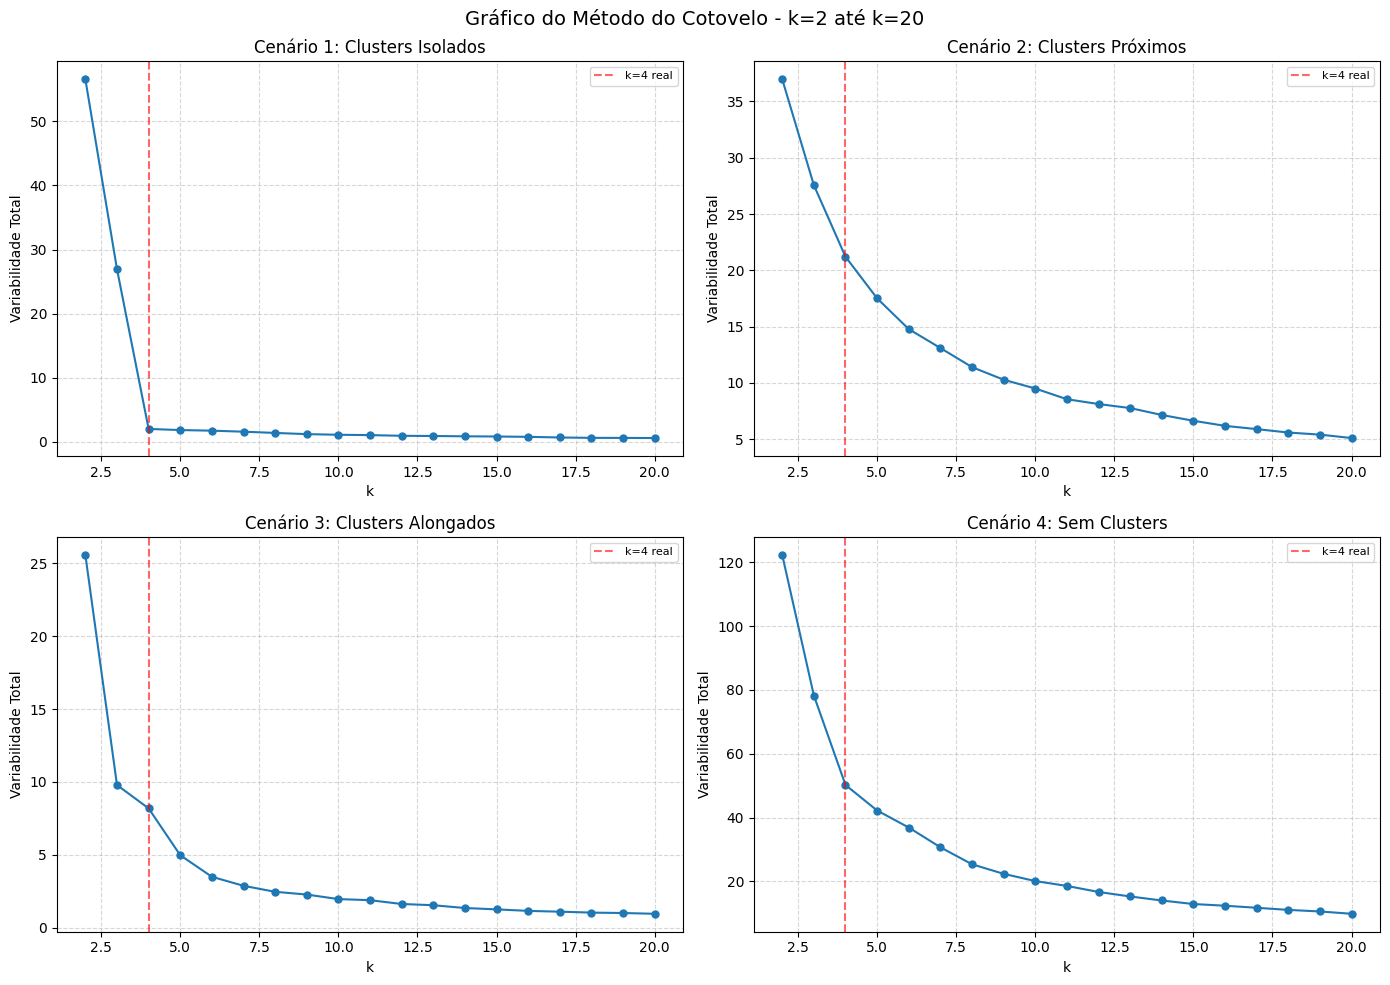

In [13]:
# Plota o gráfico do método do cotovelo para todos os cenários
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cotovelo, titulo in [
    (axes[0, 0], cotovelo1, 'Cenário 1: Clusters Isolados'),
    (axes[0, 1], cotovelo2, 'Cenário 2: Clusters Próximos'),
    (axes[1, 0], cotovelo3, 'Cenário 3: Clusters Alongados'),
    (axes[1, 1], cotovelo4, 'Cenário 4: Sem Clusters'),
]:
    ks = [r['k'] for r in cotovelo]
    vars_totais = [r['variabilidade_total'] for r in cotovelo]
    ax.plot(ks, vars_totais, marker='o', markersize=5)
    ax.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 real')
    ax.set_title(titulo)
    ax.set_xlabel('k')
    ax.set_ylabel('Variabilidade Total')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Gráfico do Método do Cotovelo - k=2 até k=20', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Tabela detalhada do cotovelo para o Cenário 1
print("Tabela do cotovelo - Cenário 1")
print(f"{'k':>4} {'Var Total':>12} {'Dissim':>10} {'Iter':>6} {'Parada':<25} {'ClusterVazio'}")
print("-" * 75)
for r in cotovelo1:
    print(f"{r['k']:>4} {r['variabilidade_total']:>12.4f} {r['dissimilaridade']:>10.4f} "
          f"{r['n_iter']:>6} {r['criterio_parada']:<25} {r['cluster_vazio']}")

Tabela do cotovelo - Cenário 1
   k    Var Total     Dissim   Iter Parada                    ClusterVazio
---------------------------------------------------------------------------
   2      56.5580     0.7840      5 centroides_sem_mudanca    False
   3      26.9386     0.6721      3 centroides_sem_mudanca    False
   4       2.0231     0.6680      3 centroides_sem_mudanca    False
   5       1.8482     0.5664     16 centroides_sem_mudanca    False
   6       1.7523     0.4926     11 centroides_sem_mudanca    False
   7       1.5934     0.5060     11 centroides_sem_mudanca    False
   8       1.3994     0.4931     11 centroides_sem_mudanca    False
   9       1.2137     0.5437     11 centroides_sem_mudanca    False
  10       1.1140     0.5661     11 centroides_sem_mudanca    False
  11       1.0602     0.5703     12 centroides_sem_mudanca    False
  12       0.9536     0.5445     12 centroides_sem_mudanca    False
  13       0.9215     0.5407     21 centroides_sem_mudanca    False
  

## 12. Comparação com scikit-learn

In [15]:
def comparar_com_sklearn(X, k, random_state=42):
    """
    Compara nossa implementação com o KMeans do scikit-learn.
    Mede tempo de execução, variabilidade, iterações e centróides.
    """
    # Nossa implementação
    t0 = time.time()
    nosso = kmeans(X, k=k, max_iter=300, tol=1e-4, random_state=random_state)
    tempo_nosso = time.time() - t0

    # scikit-learn
    t0 = time.time()
    sk = SklearnKMeans(n_clusters=k, max_iter=300, tol=1e-4,
                       random_state=random_state, n_init=1, init='random')
    sk.fit(X)
    tempo_sk = time.time() - t0

    # Variabilidade sklearn (inertia_ é exatamente a variabilidade total)
    var_sk = sk.inertia_

    return {
        'nosso': nosso,
        'tempo_nosso': tempo_nosso,
        'sk_centroides': sk.cluster_centers_,
        'sk_iter': sk.n_iter_,
        'sk_var': var_sk,
        'tempo_sk': tempo_sk,
        'sk_rotulos': sk.labels_
    }


comp1 = comparar_com_sklearn(X1_norm, k=4)
comp2 = comparar_com_sklearn(X2_norm, k=4)
comp3 = comparar_com_sklearn(X3_norm, k=4)
comp4 = comparar_com_sklearn(X4_norm, k=4)

print(f"{'Cenário':<12} {'Métrica':<25} {'Nossa Impl':>12} {'sklearn':>12}")
print("-" * 65)

for nome, comp in [('Cenário 1', comp1), ('Cenário 2', comp2),
                   ('Cenário 3', comp3), ('Cenário 4', comp4)]:
    r = comp['nosso']
    print(f"{nome:<12} {'Variabilidade Total':<25} {r['variabilidade_total']:>12.4f} {comp['sk_var']:>12.4f}")
    print(f"{nome:<12} {'Iterações':<25} {r['n_iter']:>12} {comp['sk_iter']:>12}")
    print(f"{nome:<12} {'Tempo (s)':<25} {comp['tempo_nosso']:>12.4f} {comp['tempo_sk']:>12.4f}")
    print()

Cenário      Métrica                     Nossa Impl      sklearn
-----------------------------------------------------------------
Cenário 1    Variabilidade Total             2.0231      31.4678
Cenário 1    Iterações                            3            4
Cenário 1    Tempo (s)                       0.2628       0.0658

Cenário 2    Variabilidade Total            21.2079      21.1491
Cenário 2    Iterações                           32            7
Cenário 2    Tempo (s)                       2.3756       0.0042

Cenário 3    Variabilidade Total             8.1840       6.5430
Cenário 3    Iterações                            7            6
Cenário 3    Tempo (s)                       0.4271       0.0025

Cenário 4    Variabilidade Total            50.2211      50.2276
Cenário 4    Iterações                           10           16
Cenário 4    Tempo (s)                       0.4176       0.0035



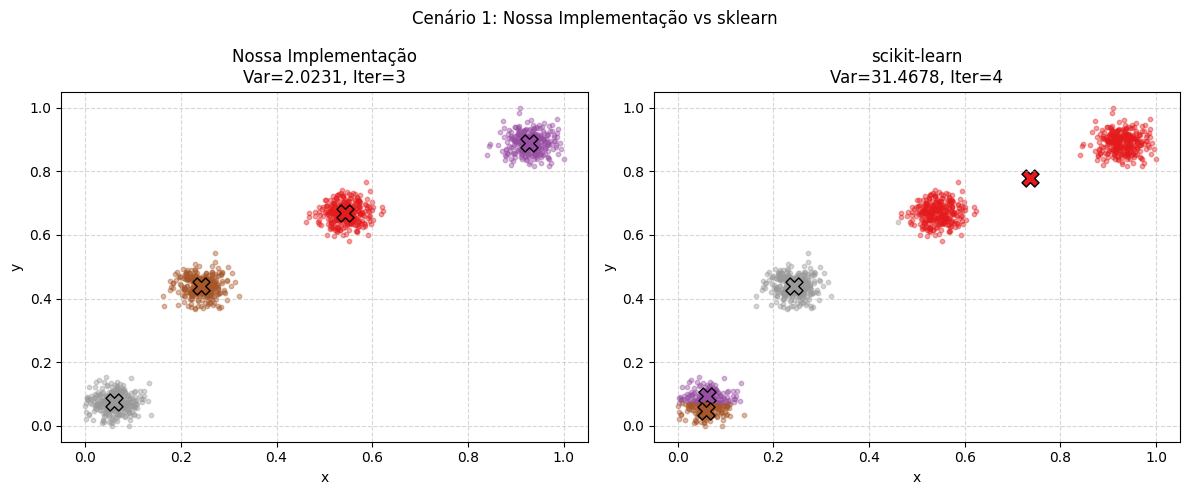

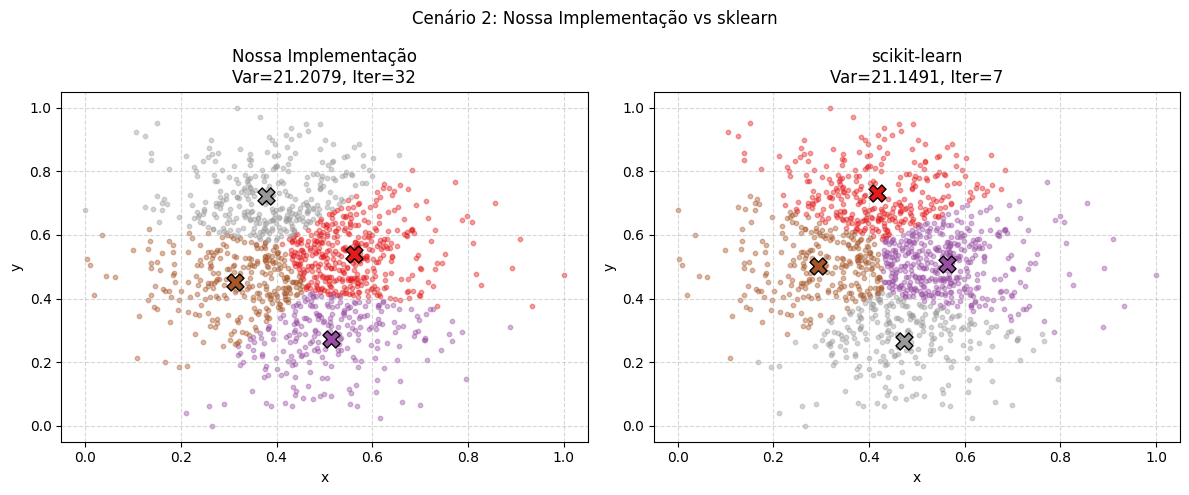

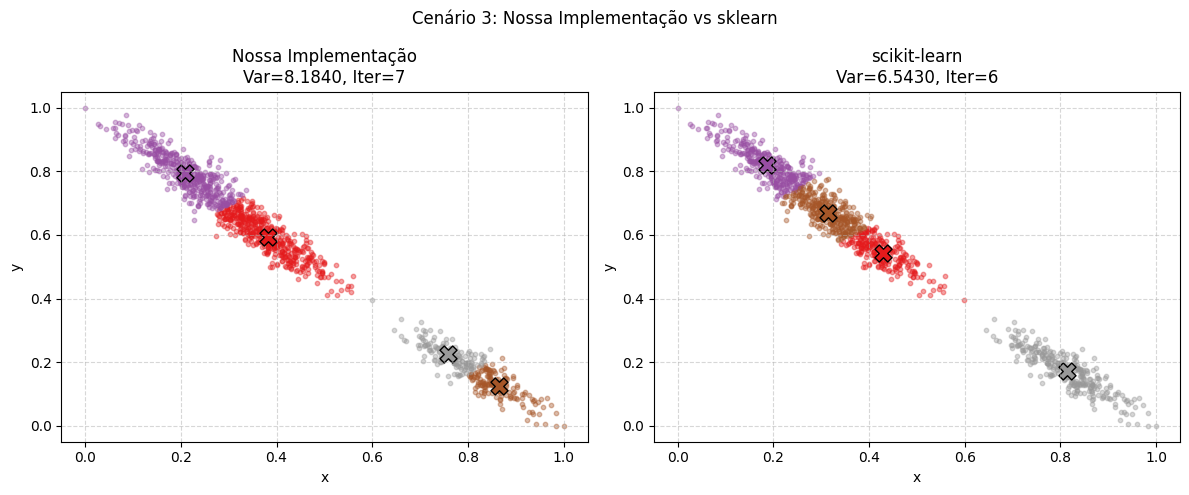

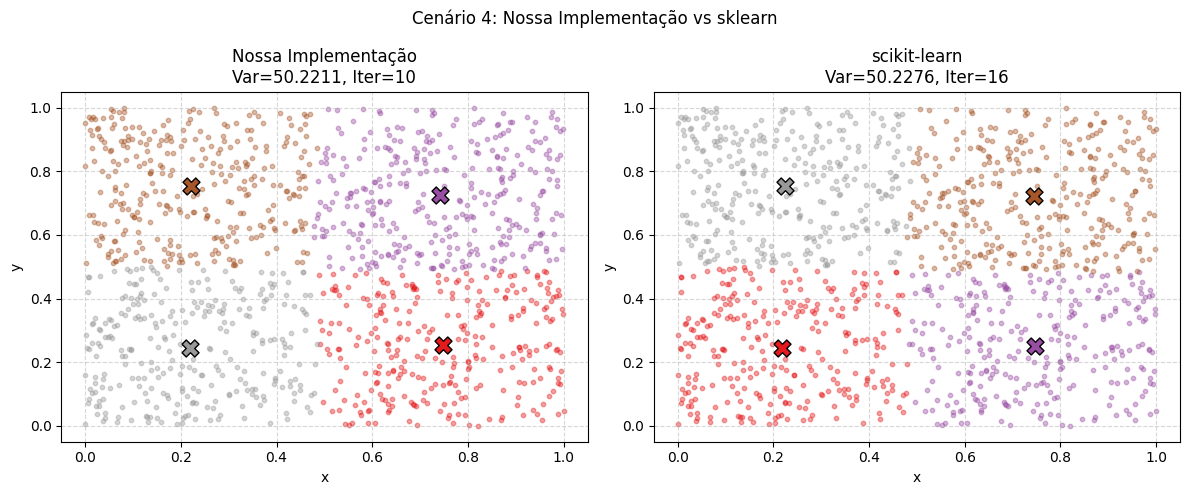

In [16]:
# Gráfico comparativo: nossa implementação vs sklearn - Cenário 1 e 2
def plotar_comparacao_sklearn(X, comp, titulo):
    """
    Plota lado a lado os clusters da nossa implementação e do sklearn.
    Permite comparar visualmente se os agrupamentos coincidiram.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    k = len(comp['nosso']['centroides'])
    cores = plt.cm.Set1(np.linspace(0, 1, k))

    # Nossa implementação
    ax = axes[0]
    for j in range(k):
        pts = X[comp['nosso']['rotulos'] == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, color=cores[j])
        ax.scatter(comp['nosso']['centroides'][j, 0], comp['nosso']['centroides'][j, 1],
                   s=150, marker='X', color=cores[j], edgecolors='black')
    ax.set_title(f'Nossa Implementação\nVar={comp["nosso"]["variabilidade_total"]:.4f}, Iter={comp["nosso"]["n_iter"]}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.5)

    # sklearn
    ax = axes[1]
    for j in range(k):
        pts = X[comp['sk_rotulos'] == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.4, color=cores[j])
        ax.scatter(comp['sk_centroides'][j, 0], comp['sk_centroides'][j, 1],
                   s=150, marker='X', color=cores[j], edgecolors='black')
    ax.set_title(f'scikit-learn\nVar={comp["sk_var"]:.4f}, Iter={comp["sk_iter"]}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


plotar_comparacao_sklearn(X1_norm, comp1, 'Cenário 1: Nossa Implementação vs sklearn')
plotar_comparacao_sklearn(X2_norm, comp2, 'Cenário 2: Nossa Implementação vs sklearn')
plotar_comparacao_sklearn(X3_norm, comp3, 'Cenário 3: Nossa Implementação vs sklearn')
plotar_comparacao_sklearn(X4_norm, comp4, 'Cenário 4: Nossa Implementação vs sklearn')